In [1]:
!pip -q install openml pandas matplotlib seaborn

In [2]:
import openml
import pandas as pd

dataset = openml.datasets.get_dataset(43627, download_all_files=True)  # credit card fraud
X, y, _, _ = dataset.get_data(target=dataset.default_target_attribute)

df = pd.concat([X, y], axis=1)

print("Shape:", df.shape)
df.head()

/tmp/ipykernel_7073/1081743013.py:4: FutureWarning: ``download_all_files`` is experimental and is likely to break with new releases.
  dataset = openml.datasets.get_dataset(43627, download_all_files=True)  # credit card fraud


Shape: (284807, 30)


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
print("Class counts:\n", df["Class"].value_counts())
print("\nClass proportion:\n", df["Class"].value_counts(normalize=True))

Class counts:
 Class
0    284315
1       492
Name: count, dtype: int64

Class proportion:
 Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64


In [4]:
print(df.dtypes)
print("\nNA counts:\n", df.isna().sum())

V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       uint8
dtype: object

NA counts:
 V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


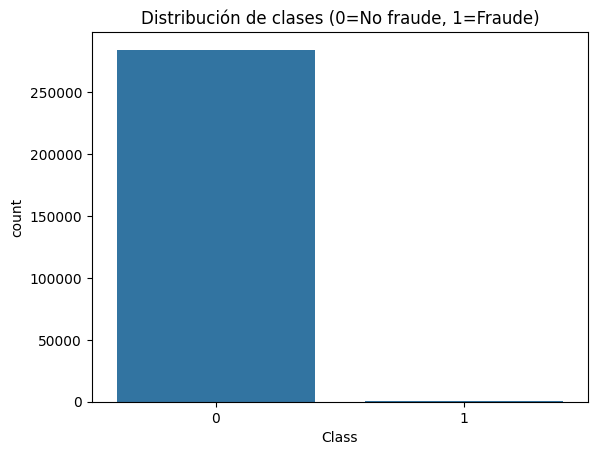

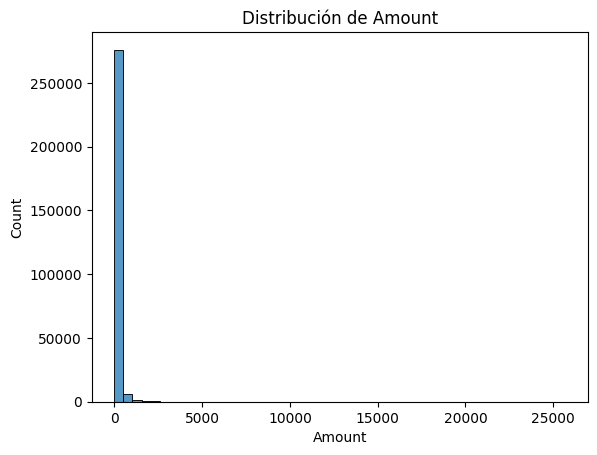

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=df, x="Class")
plt.title("Distribución de clases (0=No fraude, 1=Fraude)")
plt.show()

sns.histplot(df["Amount"], bins=50)
plt.title("Distribución de Amount")
plt.show()

In [6]:
print(df.columns)
print([c for c in df.columns if 'time' in c.lower()])

Index(['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11',
       'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21',
       'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class'],
      dtype='object')
[]


In [7]:
print(df.describe().T.head(10))  # describe

amount_q = df["Amount"].quantile([0.5, 0.75, 0.9, 0.95, 0.99, 0.999])
print("\nPercentiles Amount:\n", amount_q)

        count          mean       std         min       25%       50%  \
V1   284807.0  1.165980e-15  1.958696  -56.407510 -0.920373  0.018109   
V2   284807.0  3.416908e-16  1.651309  -72.715728 -0.598550  0.065486   
V3   284807.0 -1.373150e-15  1.516255  -48.325589 -0.890365  0.179846   
V4   284807.0  2.086869e-15  1.415869   -5.683171 -0.848640 -0.019847   
V5   284807.0  9.604066e-16  1.380247 -113.743307 -0.691597 -0.054336   
V6   284807.0  1.490107e-15  1.332271  -26.160506 -0.768296 -0.274187   
V7   284807.0 -5.556467e-16  1.237094  -43.557242 -0.554076  0.040103   
V8   284807.0  1.177556e-16  1.194353  -73.216718 -0.208630  0.022358   
V9   284807.0 -2.406455e-15  1.098632  -13.434066 -0.643098 -0.051429   
V10  284807.0  2.239751e-15  1.088850  -24.588262 -0.535426 -0.092917   

          75%         max  
V1   1.315642    2.454930  
V2   0.803724   22.057729  
V3   1.027196    9.382558  
V4   0.743341   16.875344  
V5   0.611926   34.801666  
V6   0.398565   73.301626  


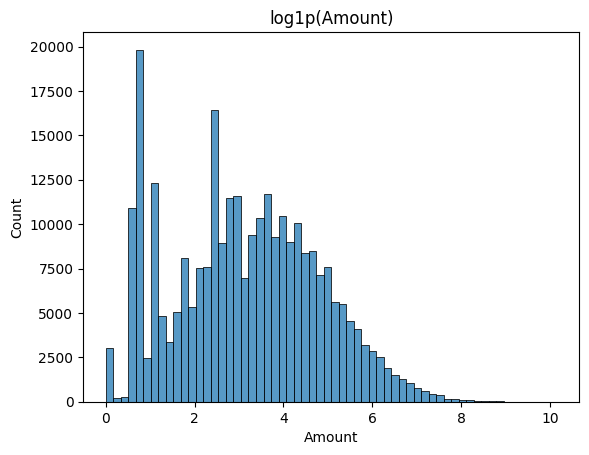

In [8]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(np.log1p(df["Amount"]), bins=60)
plt.title("log1p(Amount)")
plt.show()

In [9]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["Class"])  # target
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape

((227845, 29), (56962, 29))

In [10]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

baseline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(class_weight="balanced", max_iter=200))
])

baseline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=200))])

In [11]:
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score
)

y_prob = baseline.predict_proba(X_test)[:, 1]
y_pred = baseline.predict(X_test)

print(classification_report(y_test, y_pred, digits=4))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("Average Precision (PR-AUC):", average_precision_score(y_test, y_prob))

              precision    recall  f1-score   support

           0     0.9999    0.9746    0.9870     56864
           1     0.0586    0.9184    0.1101        98

    accuracy                         0.9745     56962
   macro avg     0.5292    0.9465    0.5486     56962
weighted avg     0.9982    0.9745    0.9855     56962

ROC-AUC: 0.9714302223421727
Average Precision (PR-AUC): 0.7181557939333807
